## Задача 1

beauty_derivative_plot

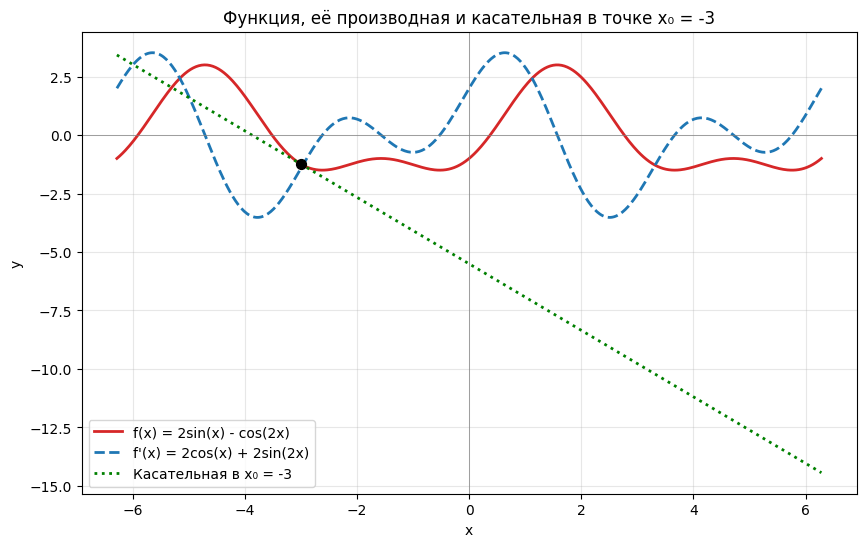

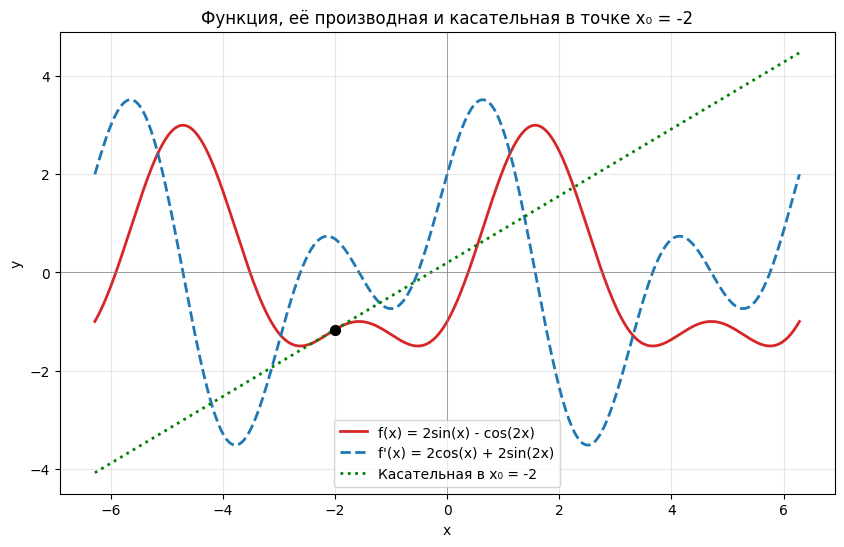

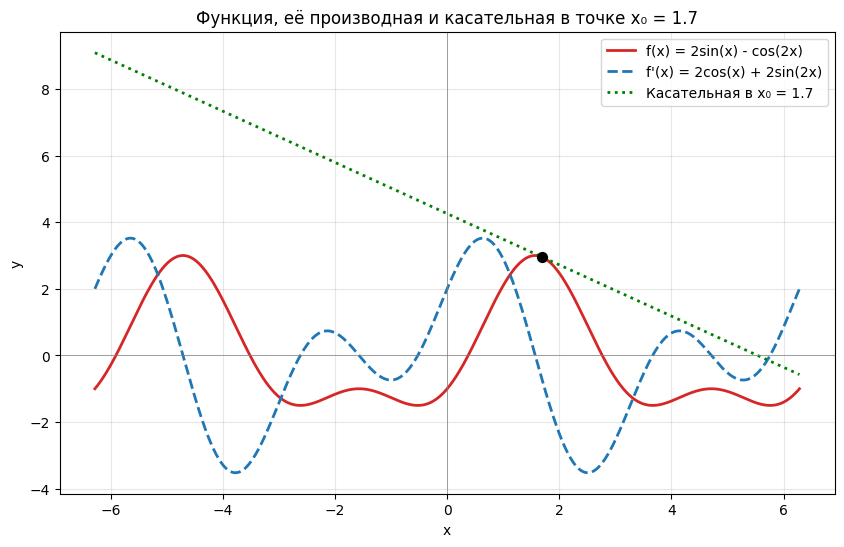

In [1]:
import numpy as np
import matplotlib.pyplot as plt
def beauty_derivative_plot(x0):
    x = np.linspace(-2*np.pi, 2*np.pi, 500)
    f = 2*np.sin(x) - np.cos(2*x)
    df = 2*np.cos(x) + 2*np.sin(2*x)
    f0 = 2*np.sin(x0) - np.cos(2*x0)
    df0 = 2*np.cos(x0) + 2*np.sin(2*x0)
    tangent = df0*(x - x0) + f0
    plt.figure(figsize=(10, 6))
    plt.plot(x, f, label='f(x) = 2sin(x) - cos(2x)', color='#d62728', linewidth=2)
    plt.plot(x, df, label="f'(x) = 2cos(x) + 2sin(2x)", color='#1f77b4', linewidth=2, linestyle='--')
    plt.plot(x, tangent, label=f'Касательная в x₀ = {x0}', color='green', linewidth=2, linestyle=':')
    plt.scatter(x0, f0, color='black', zorder=5, s=50)
    plt.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
    plt.axvline(x=0, color='gray', linestyle='-', linewidth=0.5)
    plt.legend()
    plt.title(f'Функция, её производная и касательная в точке x₀ = {x0}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid(True, alpha=0.3)
    plt.show()
beauty_derivative_plot(-3)
beauty_derivative_plot(-2)
beauty_derivative_plot(1.7)

## Задача 2

populations.txt описывают популяции зайцев, рысей и моркови в северной Канаде за 20 лет 

In [3]:
import numpy as np
import matplotlib.pyplot as plt
dane=np.loadtxt('populations.txt')
lata=dane[:,0]
zajace=dane[:,1]
rysie=dane[:,2]
marchew=dane[:,3]

### 2.1 строим график численности каждого вида по годам

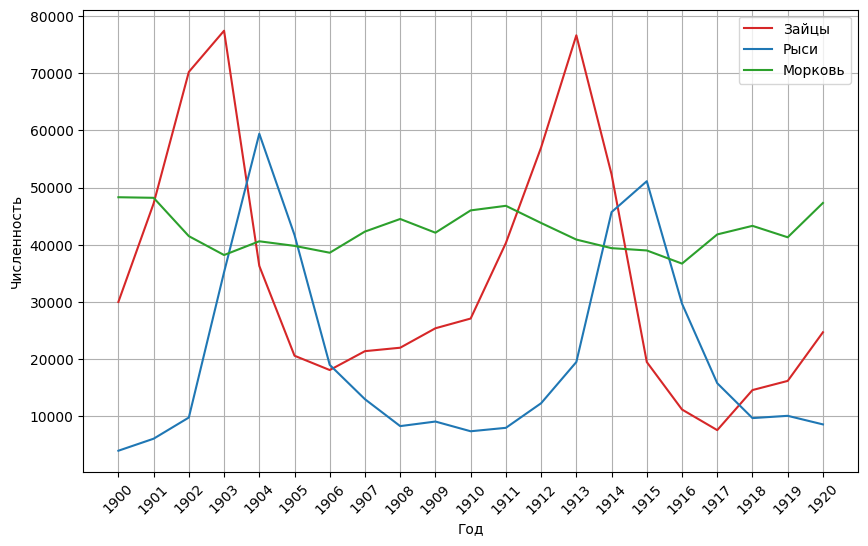

In [5]:
plt.figure(figsize=(10,6))
plt.plot(lata,zajace,color='#d62728',linestyle='-',label="Зайцы")
plt.plot(lata,rysie,color='#1f77b4',linestyle='-',label="Рыси")
plt.plot(lata,marchew,color='#2ca02c',linestyle='-',label="Морковь")
plt.legend(loc="best")
plt.xlabel("Год")
plt.ylabel("Численность")
plt.xticks(lata,rotation=45)
plt.grid(True)
plt.show()

### 2.2 ищем год максимальной численности для каждого вида

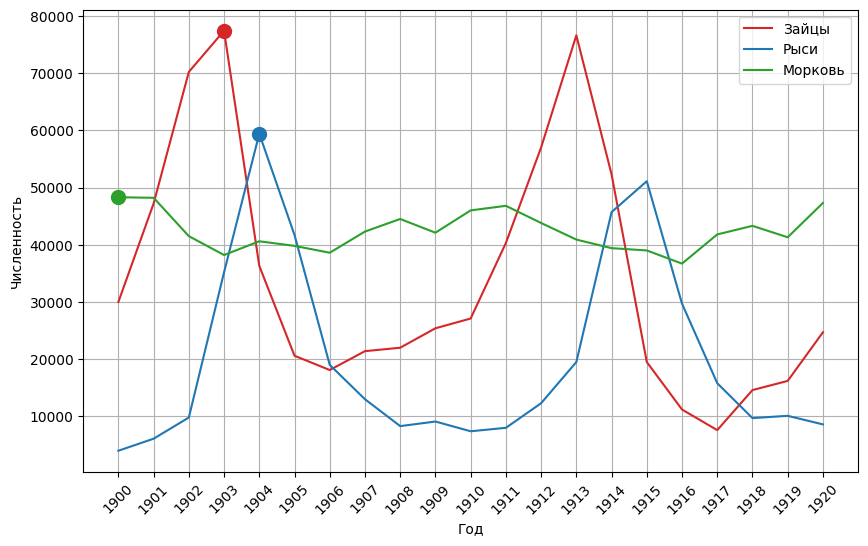

In [6]:
idx_z=np.argmax(zajace)
idx_r=np.argmax(rysie)
idx_m=np.argmax(marchew)
plt.figure(figsize=(10,6))
plt.plot(lata,zajace,color='#d62728',linestyle='-',label="Зайцы")
plt.plot(lata,rysie,color='#1f77b4',linestyle='-',label="Рыси")
plt.plot(lata,marchew,color='#2ca02c',linestyle='-',label="Морковь")
plt.plot(lata[idx_z],zajace[idx_z],'o',color='#d62728',markersize=10)
plt.plot(lata[idx_r],rysie[idx_r],'o',color='#1f77b4',markersize=10)
plt.plot(lata[idx_m],marchew[idx_m],'o',color='#2ca02c',markersize=10)
plt.legend()
plt.xlabel("Год")
plt.ylabel("Численность")
plt.xticks(lata,rotation=45)
plt.grid(True)
plt.show()

### 2.3 stacked bar graph отношения численности зайцев и рысей по годам

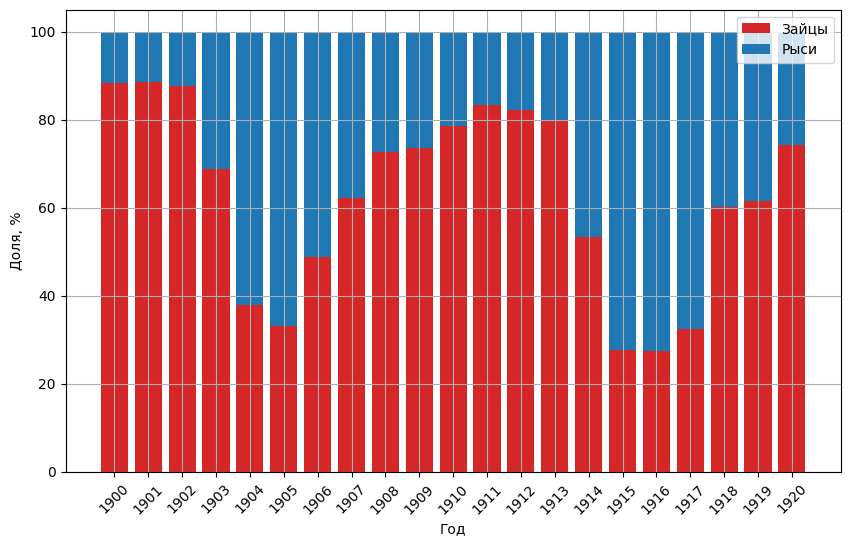

In [7]:
total=zajace+rysie
z_ratio=zajace/total*100
r_ratio=rysie/total*100
plt.figure(figsize=(10,6))
plt.bar(lata,z_ratio,label="Зайцы",color='#d62728')
plt.bar(lata,r_ratio,bottom=z_ratio,label="Рыси",color='#1f77b4')
plt.xlabel("Год")
plt.ylabel("Доля, %")
plt.xticks(lata,rotation=45)
plt.legend()
plt.grid(True)
plt.show()

### 2.4 среднее и стандартное отклонение для каждого вида

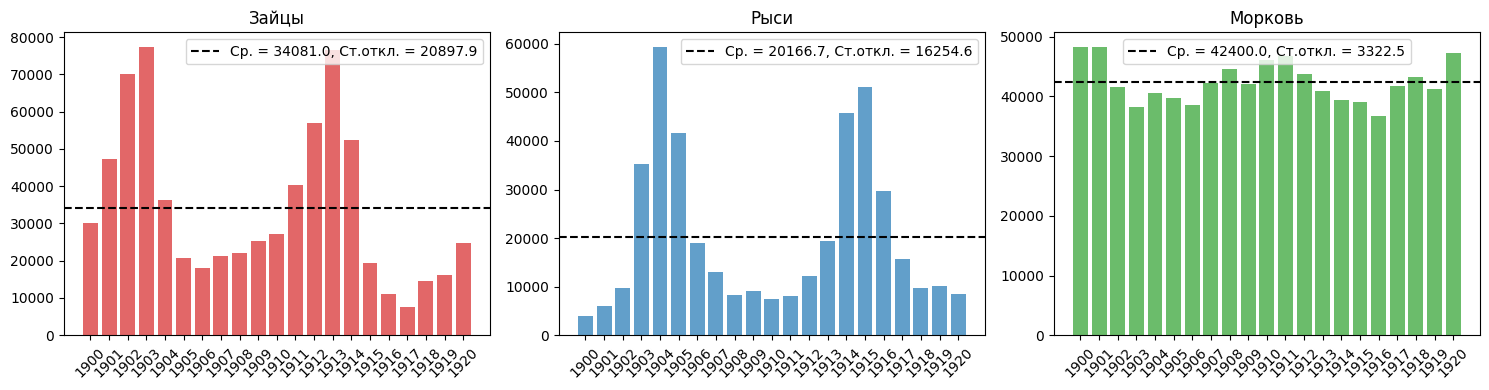

In [9]:
sr_z=np.mean(zajace); std_z=np.std(zajace)
sr_r=np.mean(rysie); std_r=np.std(rysie)
sr_m=np.mean(marchew); std_m=np.std(marchew)
plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
plt.bar(lata,zajace,color="#d62728",alpha=0.7)
plt.axhline(sr_z,linestyle='--',color='black',label=f"Ср. = {sr_z:.1f}, Ст.откл. = {std_z:.1f}")
plt.title("Зайцы")
plt.xticks(lata,rotation=45)
plt.legend()
plt.subplot(1,3,2)
plt.bar(lata,rysie,color="#1f77b4",alpha=0.7)
plt.axhline(sr_r,linestyle='--',color='black',label=f"Ср. = {sr_r:.1f}, Ст.откл. = {std_r:.1f}")
plt.title("Рыси")
plt.xticks(lata,rotation=45)
plt.legend()
plt.subplot(1,3,3)
plt.bar(lata,marchew,color="#2ca02c",alpha=0.7)
plt.axhline(sr_m,linestyle='--',color='black',label=f"Ср. = {sr_m:.1f}, Ст.откл. = {std_m:.1f}")
plt.title("Морковь")
plt.xticks(lata,rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### 2.5 какой вид преобладал каждый год

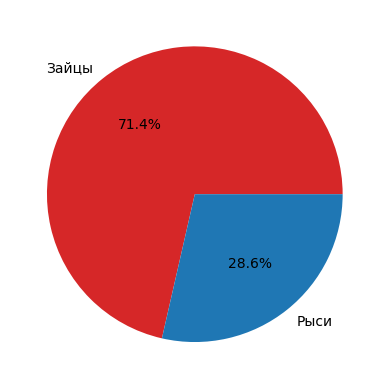

In [10]:
mask=zajace>rysie
labelki=np.where(mask,"Зайцы","Рыси")
h_count=np.sum(labelki=="Зайцы")
l_count=np.sum(labelki=="Рыси")
plt.pie([h_count,l_count],labels=["Зайцы","Рыси"],autopct="%1.1f%%",colors=["#d62728","#1f77b4"])
plt.show()

### 2.6 scatter plot численности зайцев vs рысей по годам

Коэффициент корреляции изменений: -0.1780


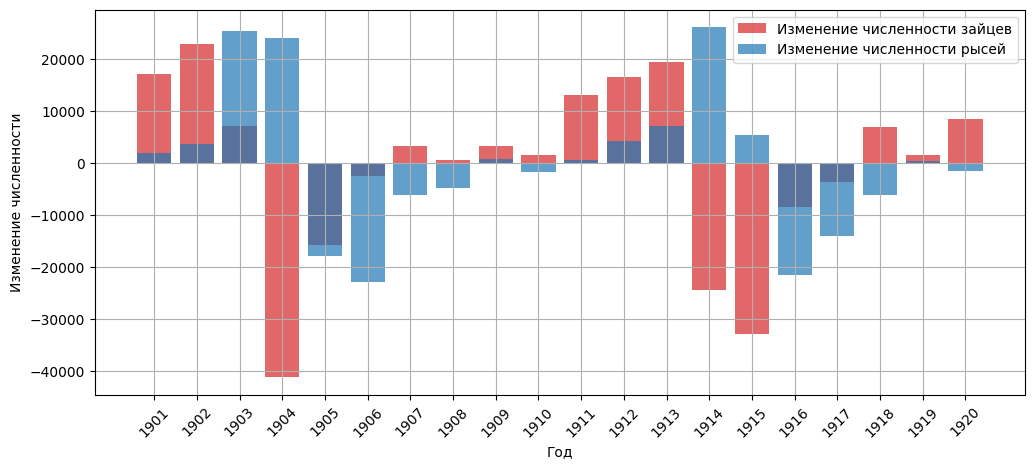

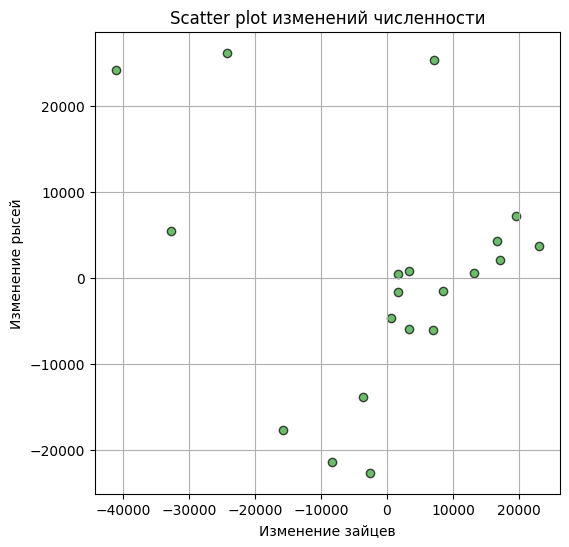

Коэффициент корреляции исходных рядов: 0.0719


In [12]:
delta_hare = zajace[1:] - zajace[:-1]
delta_lynx = rysie[1:] - rysie[:-1]
corr_changes = np.corrcoef(delta_hare, delta_lynx)[0,1]
print(f"Коэффициент корреляции изменений: {corr_changes:.4f}")
plt.figure(figsize=(12,5))
plt.bar(lata[1:], delta_hare, color='#d62728', alpha=0.7, label="Изменение численности зайцев")
plt.bar(lata[1:], delta_lynx, color='#1f77b4', alpha=0.7, label="Изменение численности рысей")
plt.xlabel("Год")
plt.ylabel("Изменение численности")
plt.xticks(lata[1:], rotation=45)
plt.legend()
plt.grid(True)
plt.show()
plt.figure(figsize=(6,6))
plt.scatter(delta_hare, delta_lynx, color='#2ca02c', edgecolors='black', alpha=0.7)
plt.xlabel("Изменение зайцев")
plt.ylabel("Изменение рысей")
plt.title("Scatter plot изменений численности")
plt.grid(True)
plt.show()
corr_orig = np.corrcoef(zajace, rysie)[0,1]
print(f"Коэффициент корреляции исходных рядов: {corr_orig:.4f}")

### 2.7 способ оценки

In [13]:
from scipy import stats
x=lata[:-1]
y=zajace[:-1]
slope,intercept,_,_,_=stats.linregress(x,y)
est1920=intercept+slope*1920
true1920=zajace[-1]
err=np.abs(est1920-true1920)/true1920
print(f"Оценка на 1920 год: {est1920:.1f}")
print(f"Истинное значение: {true1920:.1f}")
print(f"Относительная ошибка: {err:.4f}")

Оценка на 1920 год: 19775.8
Истинное значение: 24700.0
Относительная ошибка: 0.1994


линейная регрессия учитывает направление изменения

нам нужно предсказать значение за пределами обучающей выборки